In [8]:
import pandas as pd
import numpy as np
from draw_with_plot import plot_data_and_predicted
from scipy.signal import savgol_filter


In [9]:

L = 100
thate = 0.75

# 1. 读取并排序数据
df = pd.read_csv('finance.csv')
df = df.sort_values('t').reset_index(drop=True)

# 2. 对价格 y 进行光滑处理（使用 EWMA，只依赖过去和当前）
# span 参数控制平滑程度，span 越大越平滑；这里用 L 作为参考
df['y_smooth'] = df['y'].ewm(span=L, min_periods=L).mean()
# df['y_smooth'] = savgol_filter(df['y'], window_length=2*L+1, polyorder=2)

# 3. 基于光滑后的价格计算对数收益率
df['return'] = np.log(df['y_smooth'] / df['y_smooth'].shift(1))

# 4. 去掉第一行（NaN）
df = df.dropna().reset_index(drop=True)

# 5. 计算过去 L 天的滚动标准差（波动率）
df['rolling_vol'] = df['return'].rolling(window=L).std()

# 6. E_t：基于 t-1 时刻的波动率判断是否高波动
df['vol_label'] = df['rolling_vol'].shift(1)
tau = df['vol_label'].quantile(thate)
df['E_t'] = (df['vol_label'] > tau).astype(int)

# 7. 去掉因 rolling 和 shift 产生的 NaN
df = df.dropna(subset=['E_t']).reset_index(drop=True)

# 检查标签分布
print("High volatility days:", df['E_t'].sum())
print("Proportion:", df['E_t'].mean())

# 保存结果（可选：保留原始 y 和光滑后的 y_smooth）
df.to_csv('finance_with_Et_smoothed.csv', index=False)

High volatility days: 710
Proportion: 0.24149659863945577


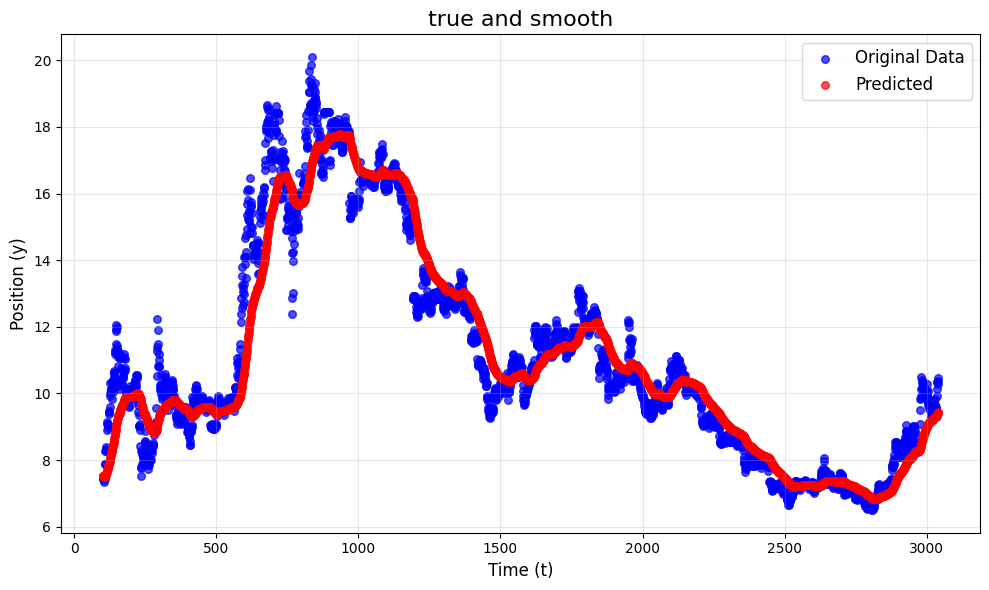

In [10]:
df1 = pd.DataFrame({'t': df['t'], 'y': df['y_smooth']})
df2 = pd.DataFrame({'t': df['t'], 'y': df['y']})

plot_data_and_predicted("true and smooth", df2, df1)

In [11]:
df1.to_csv('finance_smoothed.csv', index=False)